In [2]:
import os
import sys

PROJECT_ROOT = os.path.abspath("..")

if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

In [3]:
from src.utils import set_seed
from src.data_loader import load_dataset
from src.preprocessing import preprocess_pipeline
from src.model_mlp import (
    load_saved_model as load_mlp,
    predict as predict_mlp
)
from src.model_tabnet import (
    load_saved_model as load_tabnet,
    predict as predict_tabnet
)
from src.evaluation import regression_metrics
from src.visualization import (
    plot_prediction,
    plot_residual
)
import pandas as pd

In [4]:
set_seed()

In [5]:
df = load_dataset()

data = preprocess_pipeline(df)

[2026-07-04 19:30:00] Loading dataset : C:\Users\LENOVO\Documents\kuliah\smt 4\mlp\UAS\dataset\heartv1.csv
[2026-07-04 19:30:00] Dataset loaded successfully.
[2026-07-04 19:30:00] ============================================================
[2026-07-04 19:30:00] START PREPROCESSING
[2026-07-04 19:30:00] ============================================================
[2026-07-04 19:30:00] Duplicate removed : 723
[2026-07-04 19:30:00] Current rows      : 312
[2026-07-04 19:30:00] Missing values : 0
[2026-07-04 19:30:00] Rows removed : 0
[2026-07-04 19:30:00] Categorical features encoded.
[2026-07-04 19:30:00] Feature shape : (312, 14)
[2026-07-04 19:30:00] Target shape  : (312,)
[2026-07-04 19:30:00] Feature columns saved.
[2026-07-04 19:30:00] Dataset split completed.
[2026-07-04 19:30:00] Train      : 218
[2026-07-04 19:30:00] Validation : 47
[2026-07-04 19:30:00] Test       : 47
[2026-07-04 19:30:00] Scaler saved successfully.
[2026-07-04 19:30:00] Processed datasets saved successfully.


In [6]:
mlp = load_mlp()

tabnet = load_tabnet()

[2026-07-04 19:30:02] Loading trained MLP model...
[2026-07-04 19:30:02] Model loaded successfully.
[2026-07-04 19:30:02] TabNet model loaded.


C:\Users\LENOVO\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\pytorch_tabnet\abstract_model.py:82: UserWarning: Device used : cpu
  warnings.warn(f"Device used : {self.device}")


In [7]:
pred_mlp = predict_mlp(
    mlp,
    data["X_test"]
)

pred_tabnet = predict_tabnet(
    tabnet,
    data["X_test"]
)

In [8]:
metric_mlp = regression_metrics(
    data["y_test"],
    pred_mlp
)

metric_tabnet = regression_metrics(
    data["y_test"],
    pred_tabnet
)

[2026-07-04 19:30:27] Evaluation completed.
[2026-07-04 19:30:27] Evaluation completed.


In [9]:
comparison = pd.DataFrame({

    "Metric":[
        "MAE",
        "RMSE",
        "R2"
    ],

    "MLP":[
        metric_mlp["MAE"],
        metric_mlp["RMSE"],
        metric_mlp["R2"]
    ],

    "TabNet":[
        metric_tabnet["MAE"],
        metric_tabnet["RMSE"],
        metric_tabnet["R2"]
    ]

})

comparison

,Metric,MLP,TabNet
0,MAE,"MLP 0.781542 Name: MAE, dtype: float64","MLP 11.108101 Name: MAE, dtype: float64"
1,RMSE,"MLP 1.016644 Name: RMSE, dtype: float64","MLP 13.154308 Name: RMSE, dtype: float64"
2,R2,"MLP 0.807009 Name: R2, dtype: float64","MLP -31.309946 Name: R2, dtype: float64"


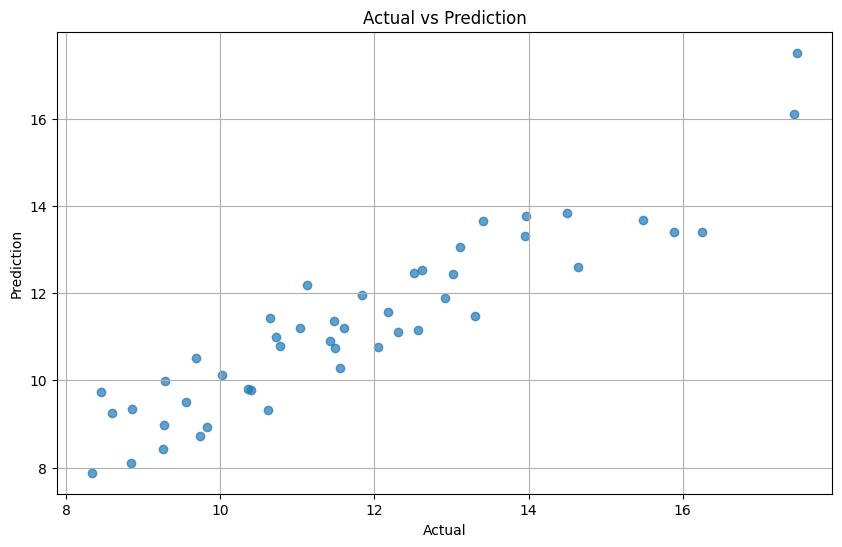

In [11]:
plot_prediction(
    data["y_test"],
    pred_mlp,
)

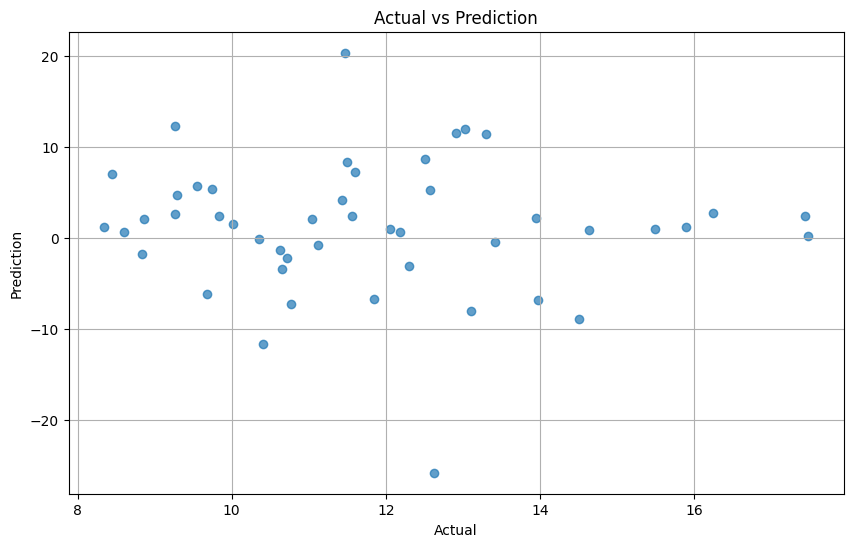

In [13]:
plot_prediction(
    data["y_test"],
    pred_tabnet,
)

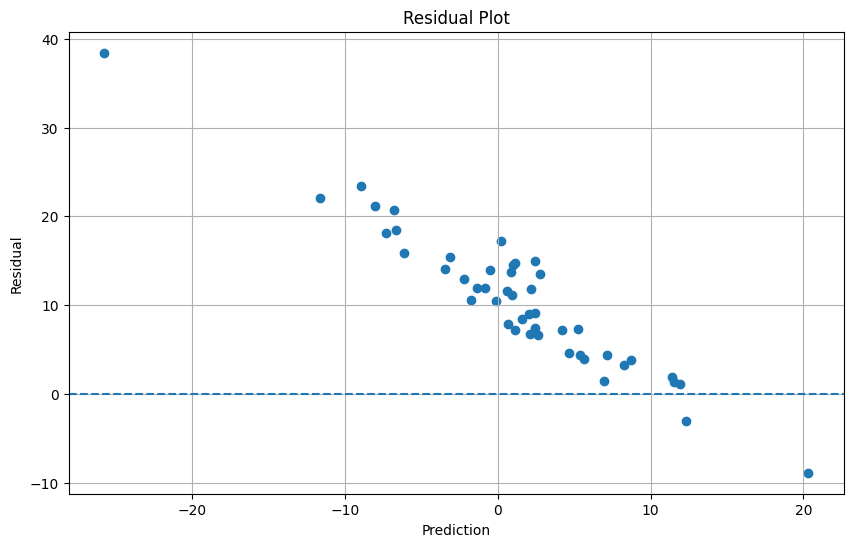

In [15]:
plot_residual(
    data["y_test"],
    pred_tabnet,
)

In [22]:
rmse_mlp = metric_mlp["RMSE"].iloc[0]
rmse_tabnet = metric_tabnet["RMSE"].iloc[0]

print("="*50)

if rmse_tabnet < rmse_mlp:
    print("Best Model : TabNet")
else:
    print("Best Model : MLP")

print("="*50)

print(comparison)

Best Model : MLP
  Metric                                         MLP  \
0    MAE   MLP    0.781542
Name: MAE, dtype: float64   
1   RMSE  MLP    1.016644
Name: RMSE, dtype: float64   
2     R2    MLP    0.807009
Name: R2, dtype: float64   

                                        TabNet  
0   MLP    11.108101
Name: MAE, dtype: float64  
1  MLP    13.154308
Name: RMSE, dtype: float64  
2    MLP   -31.309946
Name: R2, dtype: float64  
